In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
disease_df = pd.read_csv("datasets/heart.csv")
disease_df.drop(columns=["education"], inplace=True, axis=1)
disease_df.rename(columns={"male":"Sex_male"}, inplace=True)

In [4]:
disease_df.dropna(axis=0, inplace=True)
disease_df.head()

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
disease_df.shape

(3751, 15)

In [6]:
disease_df.describe()

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000
mean,0.445215,49.573447,0.488403,9.008531,0.030392,0.005599,0.311917,0.027193,236.928019,132.368435,82.938550,25.808288,75.704079,81.880032,0.152493
std,0.497056,8.570204,0.499932,11.925097,0.171686,0.074623,0.463338,0.162666,44.611594,22.046522,11.932779,4.065599,11.956382,23.882233,0.359546
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.085000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.410000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.000000,90.000000,28.060000,82.000000,87.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [7]:
print(disease_df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


In [8]:
# Splitting dataset into test and train tests
X = np.asarray(disease_df[["age", "Sex_male", "cigsPerDay", "totChol", "sysBP", "glucose"]])
Y = np.asarray(disease_df["TenYearCHD"])
X = preprocessing.StandardScaler().fit(X).transform(X)

# Training set (70% of data, X_train, Y_train)
# Testing set (30% of data, X_test, Y_test)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=4
)
print("Train set: ", X_train.shape, Y_train.shape)
print("Test set: ", X_test.shape, Y_test.shape)

Train set:  (2625, 6) (2625,)
Test set:  (1126, 6) (1126,)


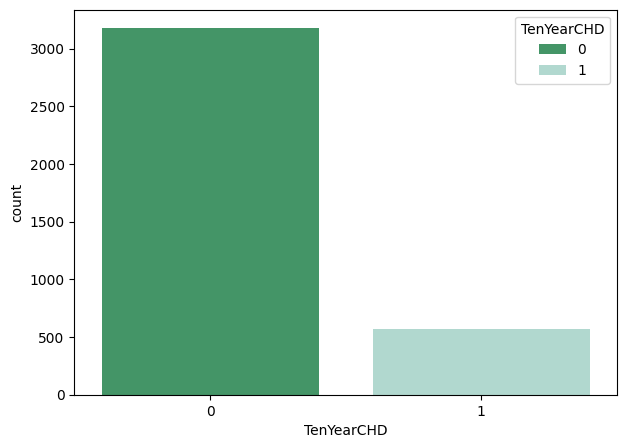

In [9]:
# Exploratory Data Analysis
plt.figure(figsize=(7,5))
sns.countplot(x="TenYearCHD", data=disease_df,
             palette="BuGn_r", hue="TenYearCHD")
plt.show()

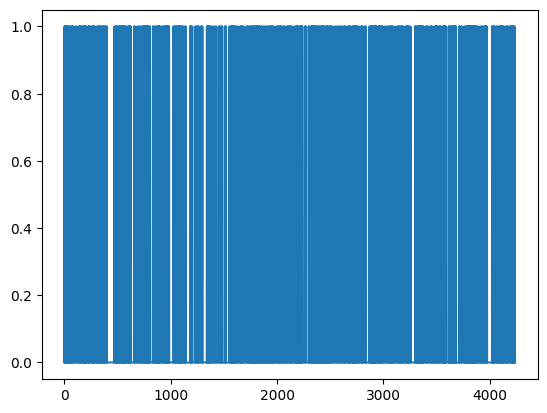

In [10]:
laste = disease_df["TenYearCHD"].plot()
plt.show(laste)

In [11]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)

In [12]:
# Evaluating Logistic Regression Model
from sklearn.metrics import accuracy_score
print("Accuracy of the model: ", accuracy_score(Y_test, Y_pred))

Accuracy of the model:  0.8490230905861457


Confusion Matrix Details:                precision    recall  f1-score   support

           0       0.85      0.99      0.92       951
           1       0.61      0.08      0.14       175

    accuracy                           0.85      1126
   macro avg       0.73      0.54      0.53      1126
weighted avg       0.82      0.85      0.80      1126



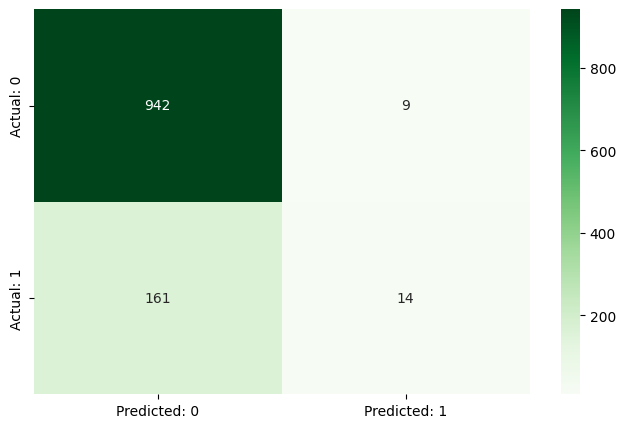

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix Details: ", classification_report(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
conf_matrix = pd.DataFrame(
    data = cm,
    columns = ["Predicted: 0", "Predicted: 1"],
    index  = ["Actual: 0", "Actual: 1"]
)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens")
plt.show()